# backtest.ipynb — Performance, riesgo y comparación de estrategias

**Propósito:** Consume los `daily_returns_XXXX.csv` de `data/signals/` y produce métricas, visualizaciones y un reporte HTML exportable. **Auto-descubre** todas las estrategias — agregar STRAT00N en `signals.ipynb` y este notebook las incorpora sin cambios.

**Flujo:**
1. Cargar todas las series de retornos de `data/signals/`
2. Calcular métricas: CAGR, Vol, Sharpe, Sortino, Calmar, MaxDD, Win rate
3. Split IS/OOS para evaluación honesta
4. Tablas comparativas y equity curves
5. Risk measures: VaR, CVaR, skewness, kurtosis
6. Retornos anuales (año a año) y correlación entre estrategias
7. Deflated Sharpe Ratio
8. Reporte HTML auto-contenido en `reports/`

**Pre-requisito:** `signals.ipynb` ya corrido.  
**Referencia:** MScFE SKILL §5, §5.2, López de Prado Ch.4

In [ ]:
# ── 0. PATHS ──────────────────────────────────────────────────────────────────
from pathlib import Path

def find_repo_root(marker: str = 'pyproject.toml') -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"No se encontró '{marker}' subiendo desde {current}")


BASE    = find_repo_root()
CONFIG  = BASE / 'config'
DATA    = BASE / 'data'
SIGNALS = DATA / 'signals'

print('BASE:   ', BASE, BASE.exists())
print('signals/ existe:', SIGNALS.exists())
signal_files = sorted(SIGNALS.glob('daily_returns_*.csv'))
print(f'Archivos de señal disponibles ({len(signal_files)}):')
for f in signal_files:
    print(f'  {f.name}')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

TRADING_DAYS = 252

try:
    cr_df     = pd.read_csv(CONFIG / 'costs_rates.csv')
    rf_annual = float(cr_df.loc[cr_df['parameter'] == 'risk_free_rate', 'value'].iloc[0])
except Exception:
    rf_annual = 0.02
    print('[warn] rf_annual=0.02 por defecto')

print(f'rf_annual: {rf_annual:.2%} | TRADING_DAYS: {TRADING_DAYS}')

rf_annual: 2.00% | TRADING_DAYS: 252


In [ ]:
# ── CARGAR TODAS LAS SERIES DE RETORNOS ───────────────────────────────────────
# Etiquetas legibles por estrategia — agregar nuevas STRAT00N aquí cuando corresponda.
# Estrategias sin etiqueta usan su ID directamente (retrocompatible).
STRAT_LABELS = {
    'STRAT001': 'Return Stacking (STRAT001)',
    'STRAT002': '60/40 SPY/AGG (STRAT002)',
    'STRAT003': 'Trend Following (STRAT003)',
    'STRAT004': 'Permanent Portfolio (STRAT004)',
    'STRAT005': 'Dual Momentum (STRAT005)',
}

all_returns = {}
for csv_path in sorted(SIGNALS.glob('daily_returns_*.csv')):
    strat_id = csv_path.stem.replace('daily_returns_', '')
    label    = STRAT_LABELS.get(strat_id, strat_id)
    df       = pd.read_csv(csv_path, parse_dates=['date'], index_col='date')
    all_returns[label] = df['daily_return'].dropna()
    print(f'  {label}: {len(all_returns[label])} obs | '
          f'{all_returns[label].index.min().date()} → {all_returns[label].index.max().date()}')

if not all_returns:
    raise FileNotFoundError('No hay archivos en data/signals/. Correr signals.ipynb primero.')

print(f'\n{len(all_returns)} estrategias cargadas.')

In [4]:
# ── FUNCIONES DE MÉTRICAS ─────────────────────────────────────────────────────
# Ref: MScFE SKILL §5.1 (performance_summary)

def compute_cagr(returns_daily: pd.Series, n_periods: int = TRADING_DAYS) -> float:
    """CAGR desde retornos diarios (compounding geométrico). MScFE SKILL §2.2."""
    n_years    = len(returns_daily) / n_periods
    cum_return = (1 + returns_daily).prod()
    return float(cum_return ** (1 / n_years) - 1)

def compute_annualized_vol(returns_daily: pd.Series, n_periods: int = TRADING_DAYS) -> float:
    """Vol anualizada: std_diaria × √252. MScFE SKILL §2.2."""
    return float(returns_daily.std() * np.sqrt(n_periods))

def compute_sharpe(returns_daily: pd.Series, rf: float = rf_annual,
                   n_periods: int = TRADING_DAYS) -> float:
    """
    Sharpe ratio anualizado. MScFE SKILL §5.1.
    EXAM INSIGHT: Annualize daily Sharpe by ×√252, never use daily Sharpe directly.
    """
    excess_daily = returns_daily - rf / n_periods
    if returns_daily.std() == 0:
        return np.nan
    return float(excess_daily.mean() / returns_daily.std(ddof=1) * np.sqrt(n_periods))

def compute_sortino(returns_daily: pd.Series, rf: float = rf_annual,
                    n_periods: int = TRADING_DAYS) -> float:
    """Sortino: usa solo retornos negativos en el denominador. MScFE SKILL §5.1."""
    ann_ret      = compute_cagr(returns_daily, n_periods)
    downside     = returns_daily[returns_daily < 0]
    downside_vol = downside.std() * np.sqrt(n_periods) if len(downside) > 0 else np.nan
    if not downside_vol or downside_vol == 0:
        return np.nan
    return float((ann_ret - rf) / downside_vol)

def compute_max_drawdown(returns_daily: pd.Series) -> float:
    """Max drawdown desde retornos simples. MScFE SKILL §5.1."""
    equity_curve = (1 + returns_daily).cumprod()
    running_max  = equity_curve.cummax()
    drawdown     = (equity_curve - running_max) / running_max
    return float(drawdown.min())

def compute_calmar(returns_daily: pd.Series, n_periods: int = TRADING_DAYS) -> float:
    """Calmar = CAGR / |MaxDD|."""
    cagr   = compute_cagr(returns_daily, n_periods)
    max_dd = compute_max_drawdown(returns_daily)
    return float(-cagr / max_dd) if max_dd < 0 else np.nan

def performance_summary(returns_daily: pd.Series, name: str = 'Strategy',
                        rf: float = rf_annual) -> pd.Series:
    """Resumen completo de performance. MScFE SKILL §5.1 pattern."""
    r = returns_daily.dropna()
    return pd.Series({
        'CAGR':    compute_cagr(r),
        'Vol':     compute_annualized_vol(r),
        'Sharpe':  compute_sharpe(r, rf),
        'Sortino': compute_sortino(r, rf),
        'Calmar':  compute_calmar(r),
        'MaxDD':   compute_max_drawdown(r),
        'Win%':    float((r > 0).mean()),
        'N_obs':   len(r),
    }, name=name)

def compute_var(returns_daily: pd.Series, alpha: float = 0.05) -> float:
    """VaR histórico al nivel alpha."""
    return float(np.percentile(returns_daily.dropna(), alpha * 100))

def compute_cvar(returns_daily: pd.Series, alpha: float = 0.05) -> float:
    """CVaR (Expected Shortfall)."""
    r = returns_daily.dropna()
    return float(r[r <= compute_var(r, alpha)].mean())

def risk_summary(returns_daily: pd.Series, name: str = 'Strategy') -> pd.Series:
    """VaR, CVaR, skewness, curtosis."""
    r = returns_daily.dropna()
    return pd.Series({
        'VaR_95':   compute_var(r, 0.05),
        'CVaR_95':  compute_cvar(r, 0.05),
        'VaR_99':   compute_var(r, 0.01),
        'CVaR_99':  compute_cvar(r, 0.01),
        'Skewness': float(r.skew()),
        'Kurtosis': float(r.kurtosis()),
    }, name=name)

print('Funciones definidas: performance_summary | risk_summary | compute_sharpe | compute_max_drawdown')

Funciones definidas: performance_summary | risk_summary | compute_sharpe | compute_max_drawdown


## Split IS / OOS

López de Prado: definir IS y OOS **antes** de mirar los resultados.  
Editar las fechas de corte en la celda siguiente. OOS mínimo 20% del total.


In [5]:
# ── DEFINIR SPLIT IS / OOS ────────────────────────────────────────────────────
# EDITAR AQUÍ antes de correr el análisis.
# Una vez definido OOS, NO modificarlo para re-testear la misma estrategia.

all_start  = min(s.index.min() for s in all_returns.values())
all_end    = max(s.index.max() for s in all_returns.values())
total_days = (all_end - all_start).days

# Default: 80% IS / 20% OOS
oos_start  = all_start + pd.Timedelta(days=int(total_days * 0.80))
IS_END     = oos_start - pd.Timedelta(days=1)
OOS_START  = oos_start

print(f'Período total: {all_start.date()} → {all_end.date()}')
print(f'IS:  {all_start.date()} → {IS_END.date()}')
print(f'OOS: {OOS_START.date()} → {all_end.date()}')
print(f'Split: {(IS_END - all_start).days} / {(all_end - OOS_START).days} días')

def slice_period(returns_dict, start, end):
    return {k: v.loc[start:end] for k, v in returns_dict.items()}

returns_is  = slice_period(all_returns, all_start, IS_END)
returns_oos = slice_period(all_returns, OOS_START, all_end)

Período total: 2022-12-29 → 2026-06-18
IS:  2022-12-29 → 2025-10-06
OOS: 2025-10-07 → 2026-06-18
Split: 1012 / 254 días


In [6]:
# ── TABLA DE PERFORMANCE IS / OOS ─────────────────────────────────────────────

perf_is  = pd.DataFrame({k: performance_summary(v, k) for k, v in returns_is.items()}).T
perf_oos = pd.DataFrame({k: performance_summary(v, k) for k, v in returns_oos.items()}).T

def format_perf(df):
    d = df.copy()
    for col in ['CAGR', 'Vol', 'MaxDD', 'Win%']:
        if col in d.columns:
            d[col] = d[col].map('{:.2%}'.format)
    for col in ['Sharpe', 'Sortino', 'Calmar']:
        if col in d.columns:
            d[col] = d[col].map(lambda x: f'{x:.2f}' if pd.notna(x) else 'NaN')
    return d

print('=' * 60)
print('IN-SAMPLE (IS)')
print('=' * 60)
print(format_perf(perf_is).to_string())

print()
print('=' * 60)
print('OUT-OF-SAMPLE (OOS)')
print('=' * 60)
print(format_perf(perf_oos).to_string())

IN-SAMPLE (IS)
            CAGR    Vol  Sharpe Sortino Calmar    MaxDD    Win%   N_obs
STRAT001   9.48%  8.58%    0.87    1.05   0.99   -9.60%  37.71%  1013.0
STRAT002  10.58%  8.26%    1.02    1.26   0.93  -11.40%  38.10%  1013.0
STRAT003  -8.88%  0.34%  -33.20  -40.09  -0.28  -31.17%   5.43%  1013.0

OUT-OF-SAMPLE (OOS)
            CAGR     Vol  Sharpe Sortino Calmar    MaxDD    Win%  N_obs
STRAT001  11.54%  15.68%    0.65    0.60   0.91  -12.72%  43.53%  255.0
STRAT002   7.06%   7.44%    0.68    0.82   1.19   -5.95%  38.82%  255.0
STRAT003  -9.45%   0.31%  -38.47  -45.67  -0.99   -9.51%   4.31%  255.0


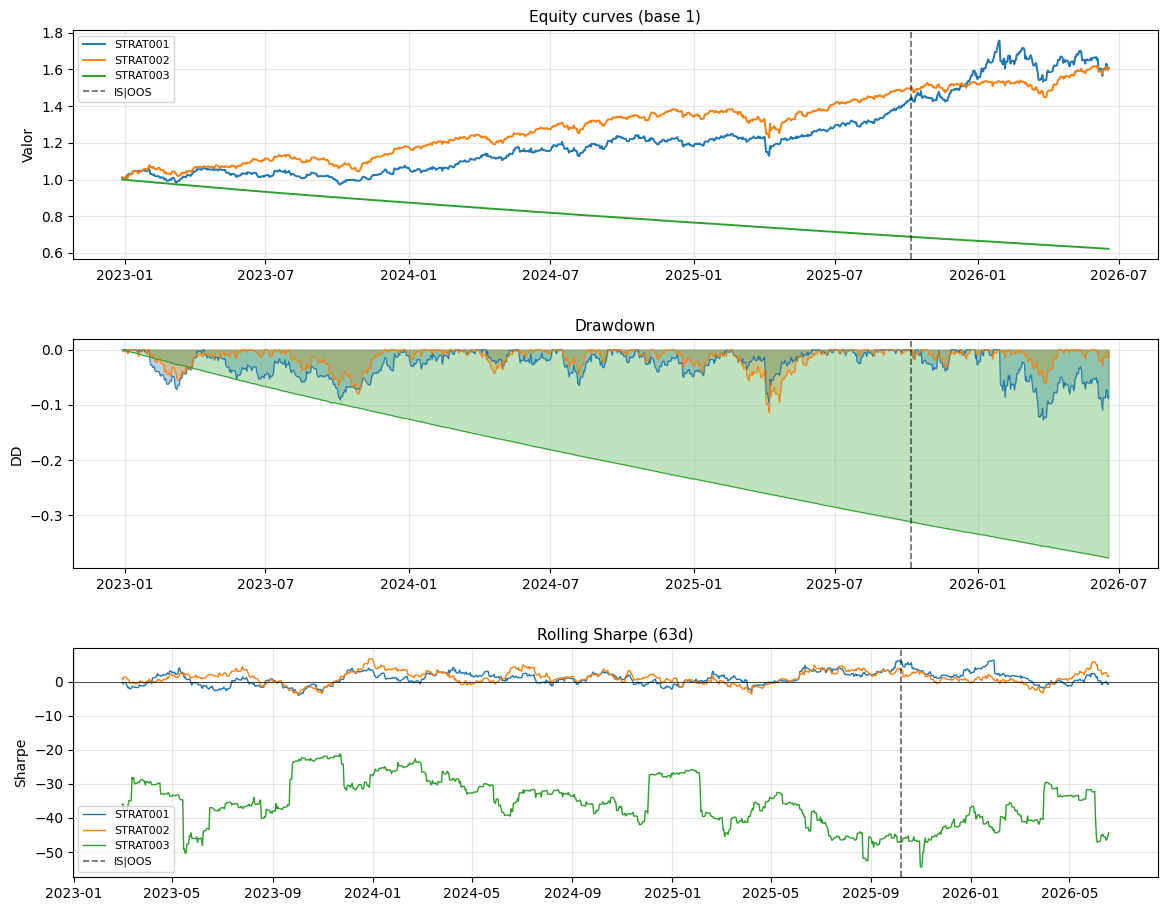

In [7]:
# ── EQUITY CURVES + DRAWDOWN + ROLLING SHARPE ─────────────────────────────────

COLORS         = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
WINDOW_ROLLING = 63

fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(3, 1, hspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

for (name, ret_series), color in zip(all_returns.items(), COLORS):
    r           = ret_series.dropna()
    equity      = (1 + r).cumprod()
    drawdown    = equity / equity.cummax() - 1
    roll_excess = r.rolling(WINDOW_ROLLING).mean() * TRADING_DAYS - rf_annual
    roll_vol    = r.rolling(WINDOW_ROLLING).std() * np.sqrt(TRADING_DAYS)
    roll_sharpe = roll_excess / roll_vol

    ax1.plot(equity,      label=name, color=color, linewidth=1.4)
    ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.3, color=color)
    ax2.plot(drawdown,    color=color, linewidth=0.7)
    ax3.plot(roll_sharpe, color=color, linewidth=1.0, label=name)

for ax in [ax1, ax2, ax3]:
    ax.axvline(OOS_START, color='black', linewidth=1.2, linestyle='--', alpha=0.6, label='IS|OOS')

ax1.set_title('Equity curves (base 1)', fontsize=11)
ax1.legend(fontsize=8); ax1.grid(alpha=0.3); ax1.set_ylabel('Valor')
ax2.set_title('Drawdown', fontsize=11)
ax2.grid(alpha=0.3); ax2.set_ylabel('DD')
ax3.set_title(f'Rolling Sharpe ({WINDOW_ROLLING}d)', fontsize=11)
ax3.axhline(0, color='k', linewidth=0.5)
ax3.legend(fontsize=8); ax3.grid(alpha=0.3); ax3.set_ylabel('Sharpe')

plt.savefig(DATA / 'equity_curves.png', dpi=120, bbox_inches='tight')
plt.show()

=== RISK MEASURES (período completo) ===
           VaR_95  CVaR_95   VaR_99  CVaR_99 Skewness Kurtosis
STRAT001  -0.963%  -1.638%  -2.065%  -3.016%   -1.045   12.590
STRAT002  -0.751%  -1.169%  -1.282%  -1.927%    0.964   22.866
STRAT003  -0.059%  -0.073%  -0.079%  -0.098%    0.831    4.181


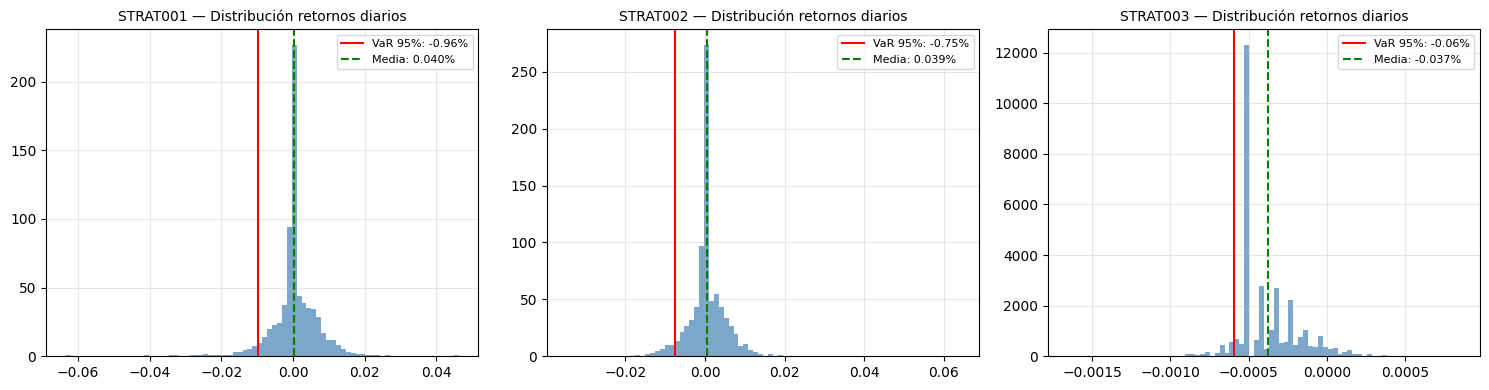

In [8]:
# ── RISK MEASURES ─────────────────────────────────────────────────────────────

risk_table = pd.DataFrame({k: risk_summary(v, k) for k, v in all_returns.items()}).T

def format_risk(df):
    d = df.copy()
    for col in ['VaR_95', 'CVaR_95', 'VaR_99', 'CVaR_99']:
        if col in d.columns:
            d[col] = d[col].map('{:.3%}'.format)
    for col in ['Skewness', 'Kurtosis']:
        if col in d.columns:
            d[col] = d[col].map('{:.3f}'.format)
    return d

print('=== RISK MEASURES (período completo) ===')
print(format_risk(risk_table).to_string())

fig, axes = plt.subplots(1, len(all_returns), figsize=(5 * len(all_returns), 4), sharey=False)
if len(all_returns) == 1:
    axes = [axes]

for (name, ret_series), ax in zip(all_returns.items(), axes):
    r = ret_series.dropna()
    ax.hist(r, bins=80, alpha=0.7, color='steelblue', density=True, edgecolor='none')
    var95 = compute_var(r, 0.05)
    ax.axvline(var95, color='red',   linewidth=1.5, label=f'VaR 95%: {var95:.2%}')
    ax.axvline(r.mean(), color='green', linewidth=1.5, linestyle='--', label=f'Media: {r.mean():.3%}')
    ax.set_title(f'{name} — Distribución retornos diarios', fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── RETORNOS ANUALES POR ESTRATEGIA ────────────────────────────────────────────
annual_ret_dict = {}
for name, ret_series in all_returns.items():
    yearly = (1 + ret_series).resample('YE').prod() - 1
    annual_ret_dict[name] = yearly

annual_ret_table = pd.DataFrame(annual_ret_dict)
annual_ret_table.index = annual_ret_table.index.year
annual_ret_table.index.name = 'Año'

print('=== RETORNOS ANUALES ===')
print(annual_ret_table.map(lambda x: f'{x:.2%}' if pd.notna(x) else '-').to_string())

In [ ]:
# ── CORRELACIÓN ENTRE ESTRATEGIAS ─────────────────────────────────────────────
returns_panel = pd.DataFrame(all_returns)
corr_matrix   = returns_panel.corr()

print('=== CORRELACIÓN (período completo) ===')
print(corr_matrix.round(3).to_string())

n = len(corr_matrix)
fig_corr, ax_corr = plt.subplots(figsize=(max(5, n * 1.4), max(4, n * 1.1)))
im = ax_corr.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax_corr, fraction=0.046, pad=0.04)

labels_short = [l.split('(')[1].rstrip(')') if '(' in l else l for l in corr_matrix.columns]
ax_corr.set_xticks(range(n)); ax_corr.set_yticks(range(n))
ax_corr.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=9)
ax_corr.set_yticklabels(labels_short, fontsize=9)
for i in range(n):
    for j in range(n):
        val = corr_matrix.iloc[i, j]
        ax_corr.text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=8, color='black' if abs(val) < 0.7 else 'white')
ax_corr.set_title('Correlación entre estrategias (período completo)', fontsize=11)
plt.tight_layout()
corr_png = DATA / 'correlation_matrix.png'
plt.savefig(corr_png, dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── DEFLATED SHARPE RATIO ─────────────────────────────────────────────────────
# Ref: MScFE SKILL §5.2, López de Prado (2016)
# Incrementar n_trials_total cada vez que se modifica una estrategia y se re-testea.

# ── EDITAR: número total de trials sobre estos datos IS ──
n_trials_total = 5

def deflated_sharpe_ratio(sharpe_observed: float, n_trials: int,
                           sharpe_std: float, n_obs: int,
                           skew: float = 0.0, kurt: float = 3.0) -> float:
    """
    DSR: probabilidad de que el Sharpe real sea > 0 ajustando por selección.
    Ref: MScFE SKILL §5.2, López de Prado (2016).
    """
    emc = 0.5772156649
    z1  = norm.ppf(1 - 1.0 / n_trials)
    z2  = norm.ppf(1 - 1.0 / (n_trials * np.e))
    expected_max_sr = sharpe_std * ((1 - emc) * z1 + emc * z2)
    numerator   = (sharpe_observed - expected_max_sr) * np.sqrt(n_obs - 1)
    denominator = np.sqrt(1 - skew * sharpe_observed + (kurt - 1) / 4.0 * sharpe_observed**2)
    if denominator == 0:
        return np.nan
    return float(norm.cdf(numerator / denominator))


sharpe_values_is = [compute_sharpe(v) for v in returns_is.values()]
sharpe_values_is = [s for s in sharpe_values_is if not np.isnan(s)]

if len(sharpe_values_is) >= 2:
    sharpe_best = max(sharpe_values_is)
    sharpe_std  = float(np.std(sharpe_values_is))
    n_obs_avg   = int(np.mean([len(v) for v in returns_is.values()]))
    dsr = deflated_sharpe_ratio(sharpe_best, n_trials_total, sharpe_std, n_obs_avg)
    print(f'=== DEFLATED SHARPE RATIO ===')
    print(f'Mejor Sharpe IS:    {sharpe_best:.3f}')
    print(f'Std Sharpe IS:      {sharpe_std:.3f}')
    print(f'n_trials_total:     {n_trials_total}')
    print(f'DSR (prob SR>0):    {dsr:.3f}')
    if dsr >= 0.95:
        print('✓ DSR ≥ 0.95 — confianza razonable')
    else:
        print('⚠ DSR < 0.95 — posible overfitting, aumentar OOS o reducir trials')
else:
    print('[INFO] Se necesitan ≥2 estrategias para calcular DSR.')

In [ ]:
# ── REPORTE HTML ───────────────────────────────────────────────────────────────
import base64
from datetime import datetime as _dt

REPORTS_DIR = BASE / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

def _png_b64(path: Path) -> str:
    return base64.b64encode(path.read_bytes()).decode('utf-8')

_css = """
<style>
* { box-sizing: border-box; }
body { font-family: 'Segoe UI', Arial, sans-serif; background: #f4f6f9;
       padding: 24px; color: #222; }
.wrap { max-width: 1140px; margin: 0 auto; background: #fff;
        padding: 40px; border-radius: 8px;
        box-shadow: 0 2px 10px rgba(0,0,0,.08); }
h1  { font-size: 22px; color: #1a1a2e; margin-bottom: 4px; }
h2  { font-size: 15px; color: #16213e; margin: 28px 0 8px;
      border-bottom: 2px solid #e4e8f0; padding-bottom: 4px; }
.meta { color: #888; font-size: 12px; margin-bottom: 20px; }
.split { background: #eef2ff; border-left: 3px solid #3a5bc7;
         padding: 8px 14px; font-size: 13px; margin-bottom: 18px;
         border-radius: 0 4px 4px 0; }
table { border-collapse: collapse; width: 100%; font-size: 12.5px; margin-bottom: 4px; }
th  { background: #1a1a2e; color: #fff; padding: 7px 11px; text-align: right; font-weight: 500; }
th:first-child { text-align: left; }
td  { padding: 5px 11px; border-bottom: 1px solid #eef0f4; text-align: right; }
td:first-child { text-align: left; font-weight: 500; }
tr:nth-child(even) td { background: #fafbfc; }
img { width: 100%; border: 1px solid #dde1ea; border-radius: 4px; margin-top: 6px; }
.dsr-ok   { color: #1e7e34; font-weight: 600; }
.dsr-warn { color: #c0392b; font-weight: 600; }
</style>
"""

_report_date = _dt.today().strftime('%Y-%m-%d')
_report_path = REPORTS_DIR / f'backtest_report_{_report_date}.html'

_parts = [
    f'<!DOCTYPE html><html lang="es"><head><meta charset="utf-8">',
    f'<title>Backtest Report {_report_date}</title>{_css}</head>',
    '<body><div class="wrap">',
    f'<h1>Portfolio Quant — Backtest Report</h1>',
    f'<p class="meta">Generado: {_report_date} &nbsp;·&nbsp; '
    f'Período: {all_start.date()} → {all_end.date()} &nbsp;·&nbsp; '
    f'rf anual: {rf_annual:.2%} &nbsp;·&nbsp; {len(all_returns)} estrategias</p>',
    f'<div class="split">IS: <strong>{all_start.date()} → {IS_END.date()}</strong>'
    f'&nbsp;&nbsp; OOS: <strong>{OOS_START.date()} → {all_end.date()}</strong></div>',

    '<h2>Performance In-Sample (IS)</h2>',
    format_perf(perf_is[['CAGR','Vol','Sharpe','Sortino','Calmar','MaxDD','Win%']]).to_html(border=0),

    '<h2>Performance Out-of-Sample (OOS)</h2>',
    format_perf(perf_oos[['CAGR','Vol','Sharpe','Sortino','Calmar','MaxDD','Win%']]).to_html(border=0),

    '<h2>Risk Measures (período completo)</h2>',
    format_risk(risk_table).to_html(border=0),

    '<h2>Retornos Anuales</h2>',
    annual_ret_table.map(lambda x: f'{x:.2%}' if pd.notna(x) else '-').to_html(border=0),

    '<h2>Correlación entre Estrategias</h2>',
    corr_matrix.round(3).to_html(border=0),
]

for _png_path, _title in [
    (DATA / 'equity_curves.png',      'Equity Curves + Drawdown + Rolling Sharpe'),
    (DATA / 'correlation_matrix.png', 'Mapa de Correlación'),
]:
    if _png_path.exists():
        _parts += [f'<h2>{_title}</h2>',
                   f'<img src="data:image/png;base64,{_png_b64(_png_path)}">']

try:
    _dsr_ok  = not np.isnan(dsr)
    _dsr_val = dsr
    _sb_val  = sharpe_best
except NameError:
    _dsr_ok = False

if _dsr_ok:
    _cls = 'dsr-ok' if _dsr_val >= 0.95 else 'dsr-warn'
    _txt = '✓ DSR ≥ 0.95 — confianza razonable' if _dsr_val >= 0.95 else '⚠ DSR < 0.95 — revisar overfitting'
    _parts += [
        '<h2>Deflated Sharpe Ratio</h2>',
        f'<p>Mejor Sharpe IS: <strong>{_sb_val:.3f}</strong> &nbsp;·&nbsp; '
        f'n_trials: <strong>{n_trials_total}</strong> &nbsp;·&nbsp; '
        f'DSR: <strong>{_dsr_val:.3f}</strong> &nbsp; '
        f'<span class="{_cls}">{_txt}</span></p>',
    ]

_parts.append('</div></body></html>')
_report_path.write_text('\n'.join(_parts), encoding='utf-8')
print(f'Reporte guardado: {_report_path}')

In [10]:
# ── RESUMEN EJECUTIVO ──────────────────────────────────────────────────────────
print('=' * 65)
print('RESUMEN EJECUTIVO — Portfolio Quant')
print(f'Período total:  {all_start.date()} → {all_end.date()}')
print(f'rf_annual:      {rf_annual:.2%} | TRADING_DAYS: {TRADING_DAYS}')
print('=' * 65)

for period_label, perf_df in [('IS', perf_is), ('OOS', perf_oos)]:
    print(f'\n--- {period_label} ---')
    print(format_perf(perf_df[['CAGR', 'Vol', 'Sharpe', 'Sortino', 'MaxDD', 'Win%']]).to_string())

print()
print('Actualizar n_trials_total en celda DSR cuando se re-testee una variante.')
print('Registrar resultados en config/portfolio_strategies.md.')

RESUMEN EJECUTIVO — Portfolio Quant
Período total:  2022-12-29 → 2026-06-18
rf_annual:      2.00% | TRADING_DAYS: 252

--- IS ---
            CAGR    Vol  Sharpe Sortino    MaxDD    Win%
STRAT001   9.48%  8.58%    0.87    1.05   -9.60%  37.71%
STRAT002  10.58%  8.26%    1.02    1.26  -11.40%  38.10%
STRAT003  -8.88%  0.34%  -33.20  -40.09  -31.17%   5.43%

--- OOS ---
            CAGR     Vol  Sharpe Sortino    MaxDD    Win%
STRAT001  11.54%  15.68%    0.65    0.60  -12.72%  43.53%
STRAT002   7.06%   7.44%    0.68    0.82   -5.95%  38.82%
STRAT003  -9.45%   0.31%  -38.47  -45.67   -9.51%   4.31%

Actualizar n_trials_total en celda DSR cuando se re-testee una variante.
Registrar resultados en config/portfolio_strategies.md.
